# Manual analysis of a single file

In [23]:
from AutomatedCellAnalysis.get_lifetimes import get_lifetimes
from AutomatedCellAnalysis.fit_lifetimes import fit_lifetimes
from pathlib import Path
from tifffile import TiffFile
from matplotlib import pyplot as plt
import numpy as np

In [85]:
out_pth_alt = Path('E:\\','Surfdrive','Screening_Data','out','Figure_AllLifetimeTraces.png')
out_pth_ltf = Path('E:\\','Surfdrive','Screening_Data','out','Figure_LifetimeTraceFitted.png')
componentfile = Path('E:\\','Surfdrive','Screening_Data','2019','12','05','binned','D07.tif')
labelmapfile = Path('E:\\','Surfdrive','Screening_Data','2019','12','05','segmented','PDE_Screen_Drow - D07_segmentation_sum_labelmap.tif')
segmentationfile = Path('E:\\','Surfdrive','Screening_Data','2019','12','05','segmented','PDE_Screen_Drow - D07_segmentation.tif')
componenttiff = TiffFile(componentfile)
labelmaptiff = TiffFile(labelmapfile)
segmentationtiff = TiffFile(segmentationfile)
forskendpoint = False
frameinterval = segmentationtiff.imagej_metadata['finterval']

In [11]:
labelmap = labelmaptiff.asarray()
intensitytraces, lifetimetraces, invalid = get_lifetimes(componenttiff.asarray(), labelmap[::2, ::2])
fitvalues = fit_lifetimes(lifetimetraces, frameinterval, forskendpoint=forskendpoint)

In [22]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-c * (x - d)))

In [106]:
N = 50
lifetimetrace = lifetimetraces[N]
fitvalue = fitvalues.iloc[N]
fitvalue

start(ns)         3.090202
range(ns)        -0.613686
half-time(s)      6.556854
midpoint(s)      64.212034
start tau(ns)     2.486068
e_start           0.014687
e_range           0.017249
e_halftime        0.451755
e_midpoint        0.767443
error             0.000000
condition              NaN
Name: 50, dtype: float64

In [107]:
x = np.arange(0,len(lifetimetrace)*frameinterval,0.1)
y = fit_function(x, fitvalue['start(ns)'], fitvalue['range(ns)'], 1/(fitvalue['half-time(s)']/np.log(2)), fitvalue['midpoint(s)'])

(0.0, 140.0)

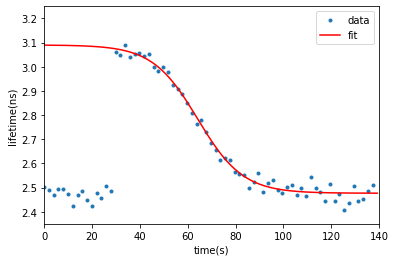

In [108]:
fig = plt.figure(1)
xax = np.arange(0,len(lifetimetrace)*frameinterval,frameinterval)
plt.plot(xax,lifetimetrace,'.',x,y,'r-')
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.legend(['data','fit'])
plt.ylim([2.35,3.25])
plt.xlim([0,140])

In [109]:
fig.savefig(out_pth_ltf,dpi=600)

(0.0, 140.0)

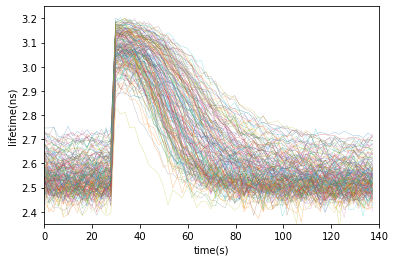

In [110]:
fig = plt.figure(2)
lifetimetraces_error_free = lifetimetraces[fitvalues['error']==0]
for lifetimetrace in lifetimetraces_error_free:
    plt.plot(xax,lifetimetrace,LineWidth=0.2)
plt.xlabel('time(s)')
plt.ylabel('lifetime(ns)')
plt.ylim([2.35,3.25])
plt.xlim([0,140])

In [111]:
fig.savefig(out_pth_alt,dpi=600)